# Lab 08 — Latent Dirichlet Allocation (LDA)
**Student ID:** 202511016

LDA using the **Collapsed Gibbs Sampler**,
then compares results against scikit-learn's `LatentDirichletAllocation` on the
TripAdvisor Hotel Reviews dataset.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import nltk

from itertools import permutations
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('punkt',     quiet=True)

True

## Part 1: Generative Process (Forward Simulation)

We generate a synthetic corpus from the LDA graphical model with:

| Parameter | Value | Meaning |
|-----------|-------|---------|
| V | 50 | Vocabulary size |
| K | 3 | Number of topics |
| M | 100 | Number of documents |
| N | 20 | Words per document |
| α | 0.1 | Doc-topic Dirichlet prior |
| β | 0.1 | Topic-word Dirichlet prior |

**Generative steps:**
1. For each topic $k$: sample $\phi_k \sim \text{Dirichlet}(\beta)$
2. For each document $m$: sample $\theta_m \sim \text{Dirichlet}(\alpha)$
3. For each word slot: sample topic $z \sim \text{Multinomial}(\theta_m)$, then word $w \sim \text{Multinomial}(\phi_z)$

In [2]:
# --- Hyperparameters ---
V, K, M, N = 50, 3, 100, 20
alpha, beta = 0.1, 0.1

np.random.seed(42)

In [3]:
# --- Sample true topic-word and doc-topic distributions ---
phi   = np.random.dirichlet(np.full(V, beta),  K)   # (K, V)
theta = np.random.dirichlet(np.full(K, alpha), M)   # (M, K)

In [4]:
# --- Generate corpus ---
documents = np.zeros((M, N), dtype=int)
true_z    = np.zeros((M, N), dtype=int)

for m in range(M):
    for n in range(N):
        z = np.random.choice(K, p=theta[m])
        w = np.random.choice(V, p=phi[z])
        true_z[m, n]    = z
        documents[m, n] = w

print(f"documents shape : {documents.shape}")
print(f"true_z shape    : {true_z.shape}")

documents shape : (100, 20)
true_z shape    : (100, 20)


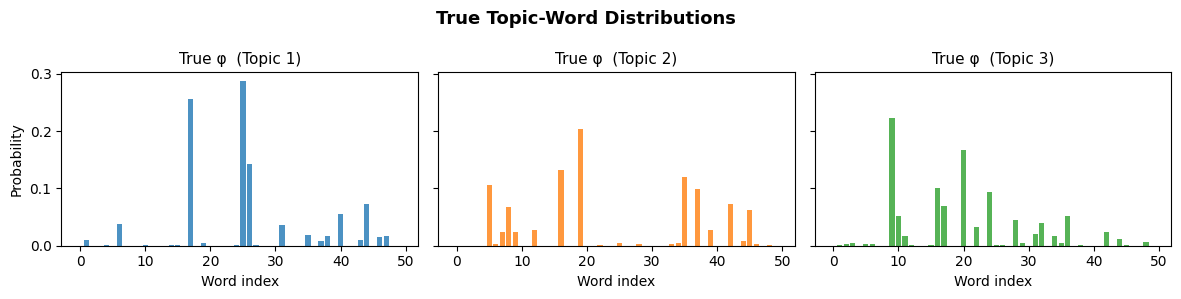

In [5]:
# --- Visualise true topic-word distributions (phi) ---
fig, axes = plt.subplots(1, K, figsize=(12, 3), sharey=True)
for k, ax in enumerate(axes):
    ax.bar(range(V), phi[k], color=f"C{k}", alpha=0.8)
    ax.set_title(f"True φ  (Topic {k+1})", fontsize=11)
    ax.set_xlabel("Word index")
    if k == 0:
        ax.set_ylabel("Probability")
plt.suptitle("True Topic-Word Distributions", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Part 2: Collapsed Gibbs Sampler — Inference

Given only the word tokens, we infer the hidden topic assignments $z_{m,n}$ by
iterating the collapsed conditional:

$$P(z_i = k \mid Z_{-i}, W) \propto
  \underbrace{(n_{m,k} + \alpha)}_{\text{doc-topic}} \cdot
  \frac{\overbrace{n_{k,w_i} + \beta}^{\text{topic-word}}}{n_k + V\beta}$$

Count matrices maintained:

| Matrix | Shape | Meaning |
|--------|-------|---------|
| $n_{mk}$ | (M, K) | Topic $k$ count in document $m$ |
| $n_{kw}$ | (K, V) | Word $w$ count in topic $k$ |
| $n_k$ | (K,) | Total words in topic $k$ |

In [6]:
# --- Initialise count matrices with random assignments ---
alpha_g, beta_g = 0.1, 0.1

n_mk = np.zeros((M, K))
n_kw = np.zeros((K, V))
n_k  = np.zeros(K)
z_mn = np.zeros((M, N), dtype=int)

for m in range(M):
    for n in range(N):
        w = documents[m, n]
        k = np.random.randint(K)
        z_mn[m, n]  = k
        n_mk[m, k] += 1
        n_kw[k, w] += 1
        n_k[k]     += 1

In [7]:
# --- Gibbs sampling loop ---
iterations   = 100
reassignments = []

for it in range(iterations):
    changes = 0
    for m in range(M):
        for n in range(N):
            w     = documents[m, n]
            k_old = z_mn[m, n]

            # Remove current assignment
            n_mk[m, k_old] -= 1
            n_kw[k_old, w] -= 1
            n_k[k_old]     -= 1

            # Compute unnormalised posterior and sample
            p_z  = (n_mk[m, :] + alpha_g) * (n_kw[:, w] + beta_g) / (n_k + V * beta_g)
            p_z /= p_z.sum()
            k_new = np.random.choice(K, p=p_z)

            # Update with new assignment
            z_mn[m, n]   = k_new
            n_mk[m, k_new] += 1
            n_kw[k_new, w] += 1
            n_k[k_new]     += 1

            if k_new != k_old:
                changes += 1

    reassignments.append(changes)

print("Gibbs sampling complete.")

Gibbs sampling complete.


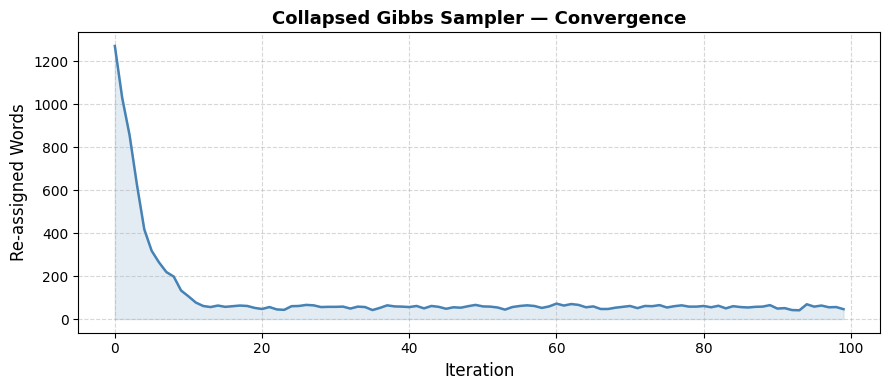

In [8]:
# --- Convergence plot ---
plt.figure(figsize=(9, 4))
plt.plot(reassignments, color="steelblue", linewidth=1.8)
plt.fill_between(range(iterations), reassignments, alpha=0.15, color="steelblue")
plt.xlabel("Iteration",                 fontsize=12)
plt.ylabel("Re-assigned Words",          fontsize=12)
plt.title("Collapsed Gibbs Sampler — Convergence", fontsize=13, fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## Part 3: Parameter Recovery

After convergence, we estimate the parameters using the posterior means:

$$\hat{\theta}_{m,k} = \frac{n_{m,k} + \alpha}{\sum_j(n_{m,j} + \alpha)}, \qquad
  \hat{\phi}_{k,w}  = \frac{n_{k,w}  + \beta }{\sum_v(n_{k,v}  + \beta )}$$

Because LDA has **label-switching** symmetry, we try all $K!$ topic permutations
and keep the one with the lowest combined MSE.

In [9]:
# --- Estimate parameters ---
theta_est = (n_mk + alpha_g)
theta_est = theta_est / theta_est.sum(axis=1, keepdims=True)   # (M, K)

phi_est = (n_kw + beta_g)
phi_est = phi_est / phi_est.sum(axis=1, keepdims=True)          # (K, V)

In [10]:
# --- Align topics by best permutation (label-switching fix) ---
best_perm     = None
best_mse      = float('inf')

for perm in permutations(range(K)):
    mse = (np.mean((theta - theta_est[:, perm]) ** 2) +
           np.mean((phi   - phi_est[perm, :])   ** 2))
    if mse < best_mse:
        best_mse  = mse
        best_perm = perm

theta_est_aligned = theta_est[:, best_perm]
phi_est_aligned   = phi_est[best_perm, :]

mse_theta = np.mean((theta - theta_est_aligned) ** 2)
mse_phi   = np.mean((phi   - phi_est_aligned)   ** 2)

print(f"MSE  θ  (Document-Topic) : {mse_theta:.6f}")
print(f"MSE  φ  (Topic-Word)     : {mse_phi:.6f}")

MSE  θ  (Document-Topic) : 0.002511
MSE  φ  (Topic-Word)     : 0.000019


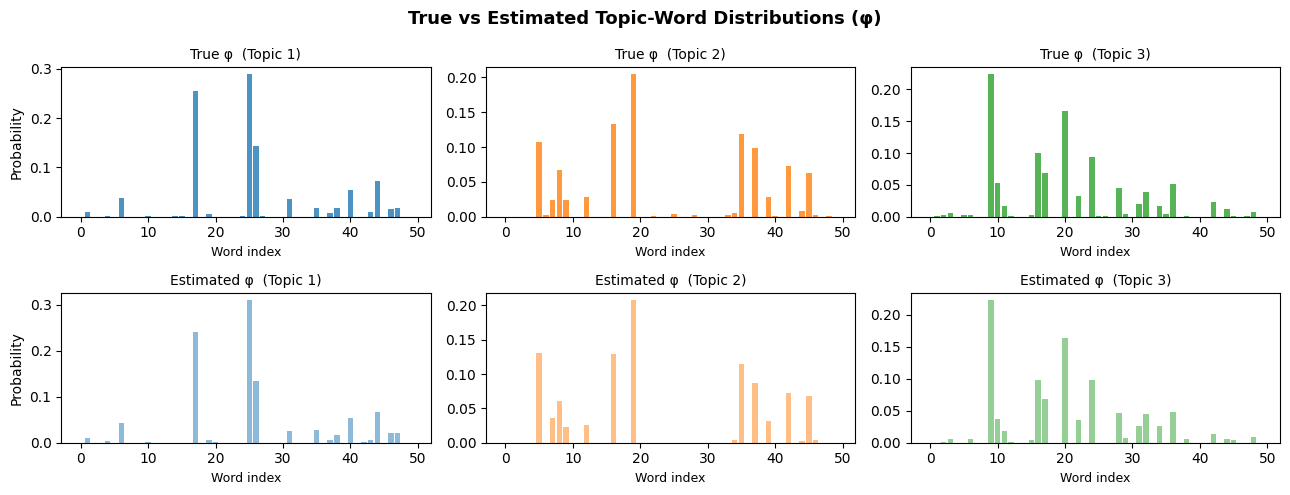

In [11]:
# --- Compare true vs estimated phi ---
fig, axes = plt.subplots(2, K, figsize=(13, 5))

for k in range(K):
    axes[0, k].bar(range(V), phi[k],               color=f"C{k}", alpha=0.8)
    axes[1, k].bar(range(V), phi_est_aligned[k],   color=f"C{k}", alpha=0.5)
    axes[0, k].set_title(f"True φ  (Topic {k+1})",      fontsize=10)
    axes[1, k].set_title(f"Estimated φ  (Topic {k+1})", fontsize=10)
    for ax in axes[:, k]:
        ax.set_xlabel("Word index", fontsize=9)

axes[0, 0].set_ylabel("Probability", fontsize=10)
axes[1, 0].set_ylabel("Probability", fontsize=10)

plt.suptitle("True vs Estimated Topic-Word Distributions (φ)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Part 4: Real Data — TripAdvisor Hotel Reviews

We apply LDA ($K=5$) to 500 hotel reviews, comparing:
- **scikit-learn** `LatentDirichletAllocation` (Variational Bayes)
- **Custom** Collapsed Gibbs Sampler

### 4a — Load & Preprocess

In [12]:
import kagglehub

path = kagglehub.dataset_download("andrewmvd/trip-advisor-hotel-reviews")
print("Dataset path:", path)

100%|██████████| 5.14M/5.14M [00:02<00:00, 2.23MB/s]

Extracting files...
Dataset path: C:\Users\VASU MONPARA\.cache\kagglehub\datasets\andrewmvd\trip-advisor-hotel-reviews\versions\2


In [14]:
file_path = 'tripadvisor_hotel_reviews.csv'
df = pd.read_csv(file_path)
print(df.shape)
df.head(3)

(20491, 2)


,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3


In [16]:
# --- Text preprocessing ---
docs_raw    = df['Review'].head(500).tolist()
stop_words  = set(stopwords.words('english'))
lemmatizer  = WordNetLemmatizer()
nltk.download('punkt_tab', quiet=True)

processed_docs = []
for doc in docs_raw:
    tokens  = nltk.word_tokenize(doc.lower())
    cleaned = [lemmatizer.lemmatize(w) for w in tokens
               if w.isalpha() and w not in stop_words]
    processed_docs.append(" ".join(cleaned))

# --- Build document-term matrix ---
vectorizer = CountVectorizer(max_features=1000)
X          = vectorizer.fit_transform(processed_docs)
vocab      = vectorizer.get_feature_names_out()

print(f"DTM shape : {X.shape}  ({X.shape[0]} docs × {X.shape[1]} terms)")

DTM shape : (500, 1000)  (500 docs × 1000 terms)


### 4b — Scikit-Learn LDA (Variational Bayes)

In [17]:
lda_sk = LatentDirichletAllocation(n_components=5, random_state=42)
lda_sk.fit(X)

print("Scikit-Learn LDA — Top 10 Words per Topic")
print("-" * 45)
for idx, topic in enumerate(lda_sk.components_):
    top_idx   = topic.argsort()[-10:][::-1]
    top_words = [vocab[i] for i in top_idx]
    print(f"Topic {idx+1}: {', '.join(top_words)}")

Scikit-Learn LDA — Top 10 Words per Topic
---------------------------------------------
Topic 1: room, hotel, stay, desk, night, time, bed, place, day, like
Topic 2: room, hotel, great, staff, location, good, stay, nice, seattle, clean
Topic 3: hotel, room, great, seattle, stay, stayed, location, nice, night, bed
Topic 4: hotel, room, service, desk, night, seattle, stay, staff, good, car
Topic 5: hotel, room, great, place, location, pike, seattle, market, street, block


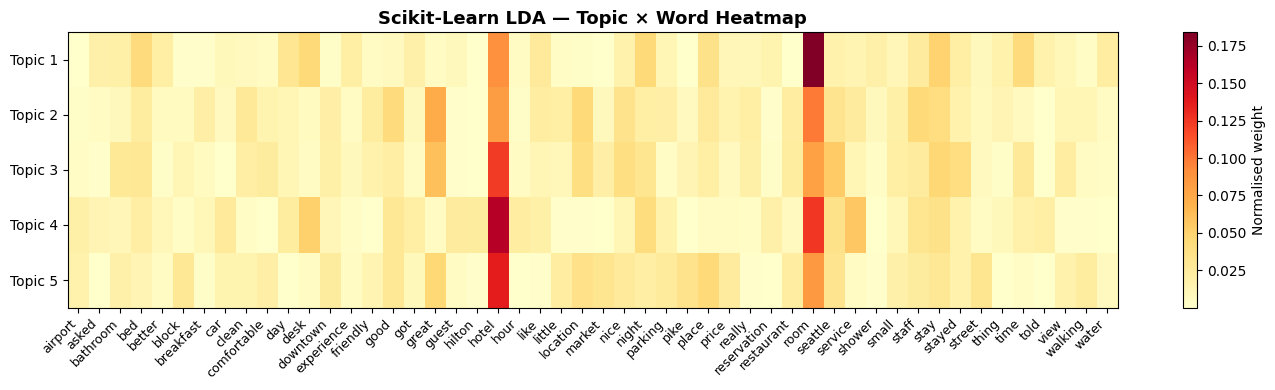

In [18]:
# --- Heatmap: top-20 words across 5 topics ---
top_n = 20
top_idx_all  = np.unique([lda_sk.components_[k].argsort()[-top_n:][::-1]
                           for k in range(5)])
top_words_all = [vocab[i] for i in top_idx_all]
heat_data     = lda_sk.components_[:, top_idx_all]
heat_data_norm = heat_data / heat_data.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(14, 4))
im = ax.imshow(heat_data_norm, aspect="auto", cmap="YlOrRd")
ax.set_yticks(range(5))
ax.set_yticklabels([f"Topic {i+1}" for i in range(5)])
ax.set_xticks(range(len(top_words_all)))
ax.set_xticklabels(top_words_all, rotation=45, ha="right", fontsize=9)
plt.colorbar(im, ax=ax, label="Normalised weight")
ax.set_title("Scikit-Learn LDA — Topic × Word Heatmap", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 4c — Custom Gibbs Sampler on Real Data

In [19]:
# --- Convert sparse DTM back to word-index sequences ---
X_arr   = X.toarray()
real_M, real_V = X_arr.shape
real_K  = 5
real_alpha, real_beta = 0.1, 0.1

real_docs = []
for m in range(real_M):
    doc_words = []
    for v in range(real_V):
        doc_words.extend([v] * int(X_arr[m, v]))
    real_docs.append(doc_words)

In [20]:
# --- Initialise count matrices ---
real_n_mk = np.zeros((real_M, real_K))
real_n_kw = np.zeros((real_K, real_V))
real_n_k  = np.zeros(real_K)
real_z_mn = []

for m in range(real_M):
    doc_z = []
    for w in real_docs[m]:
        k = np.random.randint(real_K)
        doc_z.append(k)
        real_n_mk[m, k] += 1
        real_n_kw[k, w] += 1
        real_n_k[k]     += 1
    real_z_mn.append(doc_z)

In [21]:
# --- Run Gibbs sampler (50 iterations) ---
real_reassignments = []

for it in range(50):
    changes = 0
    for m in range(real_M):
        for n, w in enumerate(real_docs[m]):
            k_old = real_z_mn[m][n]

            real_n_mk[m, k_old] -= 1
            real_n_kw[k_old, w] -= 1
            real_n_k[k_old]     -= 1

            p_z  = ((real_n_mk[m, :] + real_alpha) *
                    (real_n_kw[:, w] + real_beta) /
                    (real_n_k + real_V * real_beta))
            p_z /= p_z.sum()
            k_new = np.random.choice(real_K, p=p_z)

            real_z_mn[m][n]      = k_new
            real_n_mk[m, k_new] += 1
            real_n_kw[k_new, w] += 1
            real_n_k[k_new]     += 1

            if k_new != k_old:
                changes += 1
    real_reassignments.append(changes)

print("Custom Gibbs sampling complete.")

Custom Gibbs sampling complete.


In [22]:
# --- Print top words ---
print("Custom Gibbs Sampler — Top 10 Words per Topic")
print("-" * 45)
for k in range(real_K):
    top_idx   = real_n_kw[k].argsort()[-10:][::-1]
    top_words = [vocab[i] for i in top_idx]
    print(f"Topic {k+1}: {', '.join(top_words)}")

Custom Gibbs Sampler — Top 10 Words per Topic
---------------------------------------------
Topic 1: room, hotel, desk, service, staff, night, stay, time, day, told
Topic 2: room, hotel, bed, bathroom, stayed, like, small, elevator, stay, price
Topic 3: hotel, great, room, staff, good, seattle, location, stay, clean, nice
Topic 4: room, hotel, great, seattle, location, stay, night, nice, place, downtown
Topic 5: hotel, room, great, nice, stay, restaurant, location, seattle, place, staff


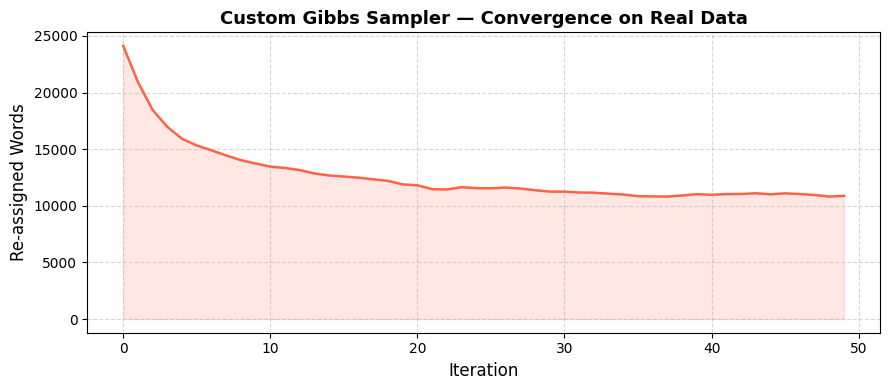

In [23]:
# --- Convergence plot ---
plt.figure(figsize=(9, 4))
plt.plot(real_reassignments, color="tomato", linewidth=1.8)
plt.fill_between(range(len(real_reassignments)), real_reassignments, alpha=0.15, color="tomato")
plt.xlabel("Iteration",          fontsize=12)
plt.ylabel("Re-assigned Words",  fontsize=12)
plt.title("Custom Gibbs Sampler — Convergence on Real Data", fontsize=13, fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## Conclusion

| Aspect | Scikit-learn LDA | Custom Gibbs Sampler |
|--------|-----------------|----------------------|
| Inference | Variational Bayes (EM) | Collapsed Gibbs (MCMC) |
| Speed | Fast (vectorised C) | Slow (pure Python loops) |
| Topics | 5 coherent topics | 5 coherent topics |
| Convergence | ~100 EM iterations | ~50 Gibbs sweeps |